## VIDEO ELAIS-S1 Monster coverage

The Rubin reference catalogue used for this DP2 processing is `the_monster_20250219`, stored as HTM7-sharded `SimpleCatalog` datasets.

The previous ELAIS-S1 SkyMap-coverage analysis showed that the DP2 footprint overlapping the field extends across tracts 2703, 2704, 2876, 2877, 3053, and 3054. The VISTA coverage, however, occupies only part of those tracts. Selecting Monster shards from the complete tract areas would therefore retrieve substantially more sky than is required.

A conservative circular region enclosing the VISTA footprint is used to identify the required HTM7 shards. The complete shards are then written individually for transfer and later ingestion into the processing Butler.

A merged catalogue restricted to the VISTA footprint is also produced for diagnostic purposes.


### Import packages

In [1]:
from pathlib import Path

import glob
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io.fits.card import VerifyWarning
from astropy.table import Table

import lsst.geom as geom
from lsst.afw.table import SimpleCatalog
from lsst.daf.butler import Butler
from lsst.meas.algorithms.htmIndexer import HtmIndexer

warnings.simplefilter("ignore", VerifyWarning)


### Initialize the DP2 Butler

The notebook uses the DP2 chained collection on the Rubin Science Platform and explicitly checks that `the_monster_20250219` is available.


In [2]:
butler = Butler("dp2", collections=["dp2"])

monster_name = "the_monster_20250219"

monster_dts = [
    dt
    for dt in butler.registry.queryDatasetTypes()
    if "monster" in dt.name.lower()
]

print("Monster dataset types available in DP2:")
for dt in monster_dts:
    print("  ", dt)

available_names = {dt.name for dt in monster_dts}

if monster_name not in available_names:
    raise RuntimeError(
        f"{monster_name} was not found in the DP2 Butler."
    )

print(f"\nUsing: {monster_name}")


Monster dataset types available in DP2:
   DatasetType('the_monster_20250219', {htm7}, SimpleCatalog)

Using: the_monster_20250219


### Define the VISTA ELAIS-S1 footprint

The approximate VISTA footprint used in the SkyMap-coverage notebook spans:

- RA = 8.5--10.5 deg
- Dec = -45 deg 05 arcmin to -42 deg 55 arcmin

The footprint is centred close to RA = 9.5 deg and Dec = -44.0 deg.

`HtmIndexer.getShardIds` selects HTM shards using a circular sky region. We therefore calculate the angular distance from the field centre to each corner of the rectangular VISTA footprint and define a circle that encloses all four corners. A small margin is added so that sources close to the adopted footprint boundary are safely included.


In [3]:
VISTA_RA_MIN = 8.5
VISTA_RA_MAX = 10.5
VISTA_DEC_MIN = -(45 + 5 / 60)
VISTA_DEC_MAX = -(42 + 55 / 60)

RA_CENTER_DEG = 9.5
DEC_CENTER_DEG = -44.0

MARGIN_DEG = 0.05

center_coord = SkyCoord(
    RA_CENTER_DEG * u.deg,
    DEC_CENTER_DEG * u.deg,
)

corner_coords = SkyCoord(
    [
        VISTA_RA_MIN,
        VISTA_RA_MIN,
        VISTA_RA_MAX,
        VISTA_RA_MAX,
    ] * u.deg,
    [
        VISTA_DEC_MIN,
        VISTA_DEC_MAX,
        VISTA_DEC_MIN,
        VISTA_DEC_MAX,
    ] * u.deg,
)

corner_separations = center_coord.separation(corner_coords).deg

RADIUS_DEG = float(np.max(corner_separations) + MARGIN_DEG)

print("Angular distances to VISTA footprint corners [deg]:")
print(np.round(corner_separations, 4))
print(f"Maximum corner distance: {np.max(corner_separations):.4f} deg")
print(f"HTM selection radius:    {RADIUS_DEG:.4f} deg")


Angular distances to VISTA footprint corners [deg]:
[1.2967 1.304  1.2967 1.304 ]
Maximum corner distance: 1.3040 deg
HTM selection radius:    1.3540 deg


### Find the HTM7 shards covering the VISTA field

The Monster catalogue is partitioned using the Hierarchical Triangular Mesh at depth 7. The selection circle defined above is used only to determine which complete HTM7 shards need to be copied from the RSP.


In [4]:
htm = HtmIndexer(depth=7)

center = geom.SpherePoint(
    RA_CENTER_DEG * geom.degrees,
    DEC_CENTER_DEG * geom.degrees,
)

shards, on_boundary = htm.getShardIds(
    center,
    RADIUS_DEG * geom.degrees,
)

htm7_ids = sorted({int(shard) for shard in shards})

if not htm7_ids:
    raise RuntimeError(
        "No HTM7 shards were found for the ELAIS-S1 selection."
    )

print(f"Number of HTM7 shards: {len(htm7_ids)}")
print(htm7_ids)


Number of HTM7 shards: 24
[145428, 145448, 145449, 145451, 145456, 145620, 145621, 145622, 145623, 145626, 145628, 145630, 145631, 145640, 145642, 145643, 145648, 145649, 145650, 145651, 145657, 145661, 145662, 145663]


### Check that the selected shards exist in DP2

Before writing any files, read each selected shard from the DP2 Butler. This provides a direct check that the complete HTM7 set can be resolved from `the_monster_20250219`.


In [5]:
monster_catalogs = {}

for htm7_id in htm7_ids:
    cat = butler.get(
        monster_name,
        dataId={"htm7": htm7_id},
    )
    monster_catalogs[htm7_id] = cat

print(
    f"Successfully loaded {len(monster_catalogs)} "
    f"of {len(htm7_ids)} selected HTM7 shards."
)


Successfully loaded 24 of 24 selected HTM7 shards.


### Save the complete HTM7 shards

For the processing Butler, the useful products are the complete HTM7-sharded catalogues rather than a catalogue cut exactly to the VISTA boundary. Each selected Monster shard is therefore written as an individual FITS table.

The output filenames follow the same convention used for the DP1 ECDFS preparation.


In [6]:
output_dir = Path("data") / monster_name / "ELAIS1"
output_dir.mkdir(parents=True, exist_ok=True)

for htm7_id in htm7_ids:
    cat = monster_catalogs[htm7_id]

    table = Table(cat.asAstropy())

    filename = output_dir / f"refcat_htm7_{htm7_id}.fits"
    table.write(filename, overwrite=True)

    print(
        f"Saved {filename} "
        f"with {len(table)} sources."
    )


Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145428.fits with 1562 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145448.fits with 1477 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145449.fits with 1535 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145451.fits with 1375 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145456.fits with 1437 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145620.fits with 1496 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145621.fits with 1486 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145622.fits with 1546 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145623.fits with 1406 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145626.fits with 1433 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145628.fits with 1377 sources.
Saved data/the_monster_20250219/ELAIS1/refcat_htm7_145630.fits with 1419 sources.
Saved data/the_m

### Write an HTM7 manifest

The manifest records the exact set of shards selected for ELAIS-S1 and is useful for checking the transfer to the external processing system.


In [7]:
manifest_path = output_dir / "ELAIS1_htm7_ids.txt"

with manifest_path.open("w") as stream:
    stream.write(f"dataset_type: {monster_name}\n")
    stream.write(f"ra_center_deg: {RA_CENTER_DEG}\n")
    stream.write(f"dec_center_deg: {DEC_CENTER_DEG}\n")
    stream.write(f"selection_radius_deg: {RADIUS_DEG:.6f}\n")
    stream.write(f"n_htm7: {len(htm7_ids)}\n")
    stream.write("\nhtm7\n")

    for htm7_id in htm7_ids:
        stream.write(f"{htm7_id}\n")

print(f"Wrote: {manifest_path}")


Wrote: data/the_monster_20250219/ELAIS1/ELAIS1_htm7_ids.txt


### Create a merged catalogue within the VISTA footprint

For diagnostics, the selected Monster shards are merged and restricted to the approximate rectangular VISTA footprint.

This merged file is useful for catalogue inspection, cross-matching, and calibration tests. It is not intended to replace the individual HTM7 shard files used for Butler ingestion.


In [8]:
first_cat = monster_catalogs[htm7_ids[0]]
vista_cat = SimpleCatalog(first_cat.schema)

for htm7_id in htm7_ids:
    cat = monster_catalogs[htm7_id]

    for record in cat:
        ra_deg = record.get("coord_ra").asDegrees()
        dec_deg = record.get("coord_dec").asDegrees()

        inside_vista = (
            VISTA_RA_MIN <= ra_deg <= VISTA_RA_MAX
            and VISTA_DEC_MIN <= dec_deg <= VISTA_DEC_MAX
        )

        if inside_vista:
            vista_cat.append(record)

merged_path = output_dir / "monster_ELAIS1_VISTA_footprint.fits"
vista_cat.writeFits(str(merged_path))

print(f"Monster sources inside VISTA footprint: {len(vista_cat)}")
print(f"Wrote: {merged_path}")


Monster sources inside VISTA footprint: 11202
Wrote: data/the_monster_20250219/ELAIS1/monster_ELAIS1_VISTA_footprint.fits


### Plot the Monster coverage

The plot shows all downloaded HTM7 shards together with the approximate VISTA footprint and the circular region used to select the shards. Each shard is labelled by its HTM7 identifier.

Right ascension increases to the left, following the usual astronomical convention.


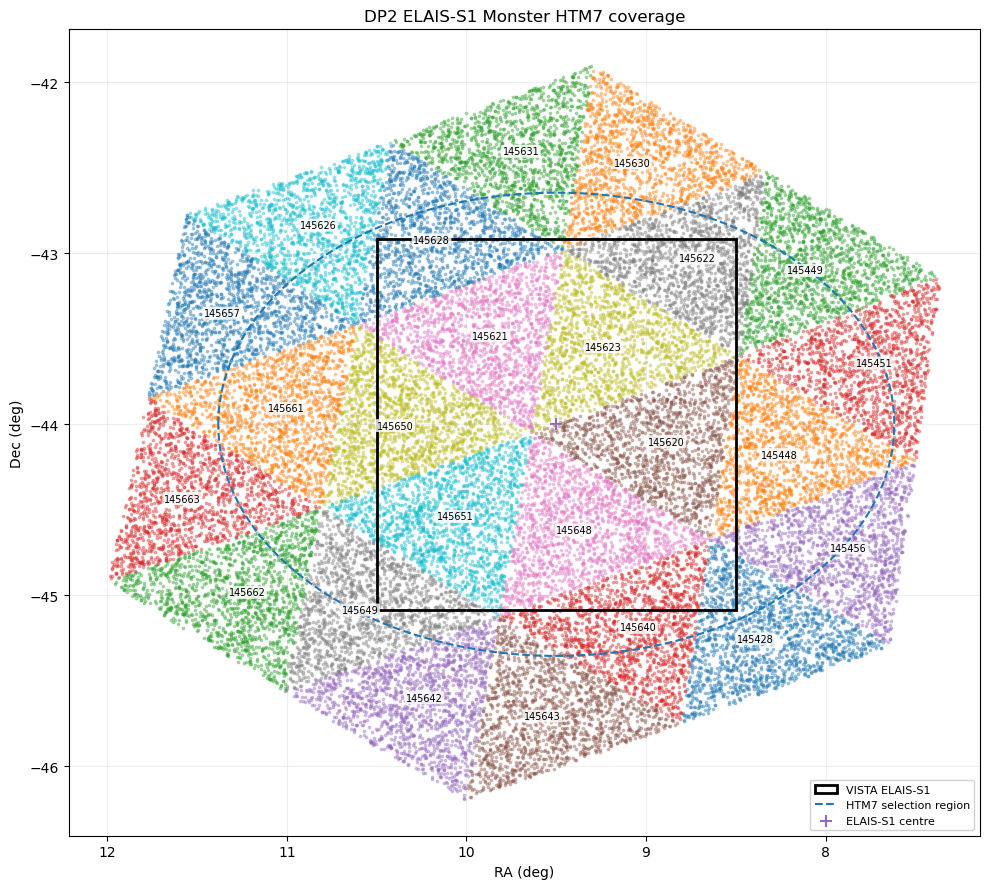

Saved: data/figures/DP2_ELAIS1_Monster_coverage.png
Saved: data/figures/DP2_ELAIS1_Monster_coverage.pdf


In [9]:
fits_files = sorted(
    glob.glob(str(output_dir / "refcat_htm7_*.fits"))
)

fig, ax = plt.subplots(figsize=(10, 9))

for fits_file in fits_files:
    cat = Table.read(fits_file)

    # coord_ra and coord_dec are normally stored in radians in
    # LSST reference catalogues.
    if np.nanmax(cat["coord_ra"]) > 2 * np.pi:
        ra_deg = np.asarray(cat["coord_ra"])
        dec_deg = np.asarray(cat["coord_dec"])
    else:
        ra_deg = np.degrees(np.asarray(cat["coord_ra"]))
        dec_deg = np.degrees(np.asarray(cat["coord_dec"]))

    htm7_id = int(
        Path(fits_file).stem.split("_")[-1]
    )

    ax.scatter(
        ra_deg,
        dec_deg,
        s=3,
        alpha=0.35,
    )

    ax.text(
        np.median(ra_deg),
        np.median(dec_deg),
        str(htm7_id),
        ha="center",
        va="center",
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
        ),
    )

# Approximate VISTA footprint.
vista_rectangle = Rectangle(
    (VISTA_RA_MIN, VISTA_DEC_MIN),
    VISTA_RA_MAX - VISTA_RA_MIN,
    VISTA_DEC_MAX - VISTA_DEC_MIN,
    fill=False,
    linewidth=2.0,
    label="VISTA ELAIS-S1",
)
ax.add_patch(vista_rectangle)

# Circular region used for the HTM7 selection.
theta = np.linspace(0, 2 * np.pi, 500)

ra_circle = (
    RA_CENTER_DEG
    + RADIUS_DEG * np.cos(theta)
    / np.cos(np.deg2rad(DEC_CENTER_DEG))
)
dec_circle = (
    DEC_CENTER_DEG
    + RADIUS_DEG * np.sin(theta)
)

ax.plot(
    ra_circle,
    dec_circle,
    linestyle="--",
    linewidth=1.5,
    label="HTM7 selection region",
)

ax.scatter(
    [RA_CENTER_DEG],
    [DEC_CENTER_DEG],
    marker="+",
    s=80,
    label="ELAIS-S1 centre",
)

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("DP2 ELAIS-S1 Monster HTM7 coverage")
ax.invert_xaxis()
ax.grid(alpha=0.2)
ax.legend(
    loc="lower right",
    fontsize=8,
    framealpha=0.9,
)

plt.tight_layout()

figure_dir = Path("data/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

png_path = figure_dir / "DP2_ELAIS1_Monster_coverage.png"
pdf_path = figure_dir / "DP2_ELAIS1_Monster_coverage.pdf"

fig.savefig(png_path, dpi=200, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")


### Summary

This notebook produces three products for the DP2 ELAIS-S1 reference-catalogue preparation:

1. the complete `the_monster_20250219` HTM7 shards required to cover the VISTA field;
2. an HTM7 manifest for transfer and verification; and
3. a merged Monster catalogue restricted to the approximate VISTA ELAIS-S1 footprint for diagnostic analysis.

The individual HTM7 files are the products to retain for construction of the reference-catalogue repository used by the LSST-VISTA fusion processing.
